# HDFS v1 — log anomaly detection with the Anomaly Detection Framework (ADF)

This notebook runs the Anomaly Detection Framework (ADF) end to end on **HDFS v1**, a public
dataset of 11.2 million log lines from a Hadoop cluster in which every data block is labelled
normal or anomalous.

| Chapter | What happens |
|---|---|
| 0 | Setup — working folder, dataset, configuration, choices |
| 1 | Data — `HDFS.log` → one file per block |
| 2 | Split — train / validation / test, at block level |
| 3 | Drain — log lines → templates |
| 4 | Embeddings — templates → vectors |
| 5 | Autoencoder — an LSTM autoencoder learns what a normal block looks like |
| 6 | Inference and evaluation — every test block gets a verdict |

**Result on the test blocks** (15,154 anomalous, 83,734 normal):

| Precision | Recall | F1 |
|---|---|---|
| 0.99279 | 0.99947 | 0.99612 |

### Two ways to run it

Every parameter behind this result is in `config.yaml` next to this notebook, and everything that
takes long to compute is in `artifacts/`: the fitted Drain parser, the template embeddings and the
trained autoencoder.

- **Reproduce the result** — the default. Chapters 3–5 load the shipped artefacts and chapter 6
  recomputes every score from the raw log. Section 6.5 compares the outcome with `config.yaml`.
- **Train your own model** — switch the choices in 0.2. Chapters 3–5 then fit the parser,
  fine-tune the embeddings and train the autoencoder with the parameters from `config.yaml`, or
  with your own.

Chapter 6 scores every block window by window and takes the longest, about 35 minutes on a laptop
CPU.

---
## 0 — Setup

### 0.1 What you need

1. **A working folder.** Everything this notebook produces is written there. Set `WORK_DIR` in the
   next cell; the folder is created if it does not exist.
2. **The dataset.** Download `HDFS_v1.zip` from the LogHub collection on Zenodo,
   <https://zenodo.org/records/8196385/files/HDFS_v1.zip?download=1>. The archive has no folder of
   its own, so unzip it into `WORK_DIR/data/HDFS_v1/`:
   ```bash
   unzip HDFS_v1.zip -d WORK_DIR/data/HDFS_v1
   ```
   These two files must then exist; both are checked against the checksums in `config.yaml`:
   ```
   WORK_DIR/data/HDFS_v1/HDFS.log
   WORK_DIR/data/HDFS_v1/preprocessed/anomaly_label.csv
   ```
3. **The base sentence transformer**,
   [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
   at the revision pinned in `config.yaml`. Chapter 4 downloads it into `WORK_DIR/models/` the
   first time it is needed.
4. **The Python environment of this repository.** In the repository root, with
   [uv](https://docs.astral.sh/uv/):
   ```bash
   uv sync --locked --extra deploy
   uv run --with jupyter jupyter lab
   ```

### 0.2 Choices

Three switches decide what is loaded and what is recomputed:

| Switch | `"ours"` | the alternative |
|---|---|---|
| `DRAIN` | load the shipped parser | `"fit"` — fit Drain on the training blocks |
| `EMBEDDINGS` | load the shipped template embeddings | `"finetune"` — fine-tune the sentence transformer here |
| `AUTOENCODER` | load the shipped model | `"train"` — train with the parameters in `config.yaml` |

With all three set to `"ours"` the notebook reproduces the published numbers exactly. What to
expect from the other combinations:

- **`EMBEDDINGS = "finetune"`** with the shipped parser and model. The fine-tuning is
  deterministic, and 4.3 compares your embeddings with the shipped ones. On the hardware the
  result was produced on — Apple Silicon, with the environment in `uv.lock` — they are identical.
- **`AUTOENCODER = "train"`**. Training on Apple Silicon (MPS) is not deterministic, so a model
  trained here scores slightly differently from the shipped one, and 6.4 chooses its threshold
  afresh, on the validation blocks and the blocks set aside for it. Expect numbers close to the
  published ones, not identical. Training takes about seven hours.
- **`DRAIN = "fit"`**. Drain finds the same 19 templates but can number them differently. The
  shipped embeddings and model are indexed by the shipped numbering, so a parser fitted here needs
  `EMBEDDINGS = "finetune"` and `AUTOENCODER = "train"` as well.

In [1]:
from __future__ import annotations

import hashlib
import json
import logging
import shutil
import time
from pathlib import Path

import warnings

import numpy as np
import polars as pl
import torch
import yaml

# Progress bars fall back to plain text when ipywidgets is not installed; the notice is noise.
warnings.filterwarnings("ignore", message="IProgress not found")

# -------------------------------------------------------------------------------------------
# YOUR SETTINGS
# -------------------------------------------------------------------------------------------
WORK_DIR = Path.home() / "adf_demos" / "hdfs"   # any folder you like; created if missing

DRAIN = "ours"          # "ours" | "fit"
EMBEDDINGS = "ours"     # "ours" | "finetune"
AUTOENCODER = "ours"    # "ours" | "train"
# -------------------------------------------------------------------------------------------

DEMO_DIR = Path.cwd()                  # the folder that holds this notebook
ARTIFACTS = DEMO_DIR / "artifacts"
CONFIG = yaml.safe_load((DEMO_DIR / "config.yaml").read_text())

DATA_DIR = WORK_DIR / "data" / "HDFS_v1"
MODELS_DIR = WORK_DIR / "models"
WORK_DIR.mkdir(parents=True, exist_ok=True)

assert DRAIN in ("ours", "fit"), DRAIN
assert EMBEDDINGS in ("ours", "finetune"), EMBEDDINGS
assert AUTOENCODER in ("ours", "train"), AUTOENCODER
if DRAIN == "fit":
    assert EMBEDDINGS == "finetune" and AUTOENCODER == "train", (
        "A parser fitted here numbers its templates on its own, and the shipped embeddings and "
        "model follow the shipped numbering. With DRAIN = 'fit' use EMBEDDINGS = 'finetune' and "
        "AUTOENCODER = 'train'.")
REPRODUCE = (DRAIN, EMBEDDINGS, AUTOENCODER) == ("ours", "ours", "ours")


def show(path: Path) -> str:
    """A path for printing — relative to WORK_DIR or to this notebook's folder."""
    path = Path(path)
    for root, name in ((WORK_DIR, "WORK_DIR"), (DEMO_DIR, ".")):
        if path == root:
            return name
        try:
            return f"{name}/{path.relative_to(root)}"
        except ValueError:
            pass
    return str(path).replace(str(Path.home()), "~")


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 24), b""):
            digest.update(chunk)
    return digest.hexdigest()


# The dataset — both files must be exactly the published ones.
contents = CONFIG["dataset"]["contents"]
LOG_PATH = DATA_DIR / contents["log"]["file"]
LABELS_PATH = DATA_DIR / contents["labels"]["file"]
for path, key in ((LOG_PATH, "log"), (LABELS_PATH, "labels")):
    assert path.exists(), f"{show(path)} not found — download and unzip {CONFIG['dataset']['url']}"
    assert sha256(path) == contents[key]["sha256"], f"{show(path)} is not the published file"
    print(f"dataset    {show(path):<56} checksum OK")

# The shipped artefacts — each must match the checksum recorded in config.yaml.
for spec in CONFIG["artifacts"].values():
    assert sha256(DEMO_DIR / spec["file"]) == spec["sha256"], f"{spec['file']} does not match config.yaml"
print(f"artefacts  {len(CONFIG['artifacts'])} files in ./artifacts, checksums OK")

# The framework logs every call of some functions at INFO; keep the notebook readable.
for name in ("adf.core.common.logger", "adf.logs.inference.inference_module",
             "adf.logs.parsers.drain.drain"):
    logging.getLogger(name).setLevel(logging.WARNING)

print(f"\nworking folder : {str(WORK_DIR).replace(str(Path.home()), '~')}")
print(f"choices        : DRAIN = {DRAIN!r}, EMBEDDINGS = {EMBEDDINGS!r}, AUTOENCODER = {AUTOENCODER!r}")
print("mode           : " + ("reproduce the published result" if REPRODUCE else "partly recomputed — see 0.2"))

dataset    WORK_DIR/data/HDFS_v1/HDFS.log                           checksum OK
dataset    WORK_DIR/data/HDFS_v1/preprocessed/anomaly_label.csv     checksum OK
artefacts  5 files in ./artifacts, checksums OK

working folder : ~/adf_demos/hdfs
choices        : DRAIN = 'ours', EMBEDDINGS = 'ours', AUTOENCODER = 'ours'
mode           : reproduce the published result


---
## 1 — Data: `HDFS.log` → one file per block

`HDFS.log` is one flat stream of 11,175,629 lines written by every node of the cluster,
interleaved. ADF works on **sequences** of log lines, and in HDFS the natural sequence is a
**block** (`blk_…`): the life of one data block, from allocation through replication to deletion.
The labels are per block as well.

This chapter

1. splits every line into `@timestamp`, `pid`, `message` and `source` (the block id),
2. attaches the block's label from `anomaly_label.csv`,
3. writes **one parquet file per block**, into `normal/` or `anomalous/`.

One file per block guarantees that a window of log lines can never cross a block boundary later.
The two folders keep training strictly on normal blocks: the autoencoder learns what healthy
operation looks like and flags whatever deviates from it.

A line has the form `Date Time Pid Level Component: Content`:

```
081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: ...
```

Rows keep **their order in the file**. Timestamps have one-second resolution, so many lines of a
block share a second; the framework sorts with a stable sort later, which leaves them in file order.

### 1.1 Parse the log

The file is read as a single text column — the separator `\x01` never occurs in the log — and split
into fields by one regular expression.

In [2]:
BLOCKS_DIR = WORK_DIR / "blocks"
NORMAL_DIR, ANOMALOUS_DIR = BLOCKS_DIR / "normal", BLOCKS_DIR / "anomalous"
for directory in (NORMAL_DIR, ANOMALOUS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

LINE_RE = r"^(\d{6}) (\d{6}) (\d+) (.*)$"     # Date Time Pid Level Component: Content
BLK_RE = r"(blk_-?\d+)"

_t0 = time.time()
raw = pl.read_csv(LOG_PATH, has_header=False, separator="\x01", quote_char=None, new_columns=["raw"])
logs = (
    raw.select(pl.col("raw").str.extract_groups(LINE_RE).alias("g"))
    .unnest("g")
    .select(
        pl.concat_str([pl.col("1"), pl.lit(" "), pl.col("2")])
        .str.to_datetime("%y%m%d %H%M%S")
        .alias("@timestamp"),
        pl.col("3").cast(pl.Int32).alias("pid"),
        pl.col("4").alias("message"),
        pl.col("4").str.extract(BLK_RE, 1).alias("source"),
    )
)
del raw
print(f"parsed {logs.height:,} lines in {time.time() - _t0:.1f} s")
logs.head(5)

parsed 11,175,629 lines in 0.6 s


@timestamp,pid,message,source
datetime[μs],i32,str,str
2008-11-09 20:35:18,143,"""INFO dfs.DataNode$DataXceiver:…","""blk_-1608999687919862906"""
2008-11-09 20:35:18,35,"""INFO dfs.FSNamesystem: BLOCK* …","""blk_-1608999687919862906"""
2008-11-09 20:35:19,143,"""INFO dfs.DataNode$DataXceiver:…","""blk_-1608999687919862906"""
2008-11-09 20:35:19,145,"""INFO dfs.DataNode$DataXceiver:…","""blk_-1608999687919862906"""
2008-11-09 20:35:19,145,"""INFO dfs.DataNode$PacketRespon…","""blk_-1608999687919862906"""


### 1.2 Check the parsing

Nothing may be lost or mangled before the data is scattered across half a million files: no field
may be empty, and every line must name exactly one block. Some lines mention the same block twice —
`Deleting block blk_X file /…/blk_X` — which is why the first match is taken.

In [3]:
nulls = logs.null_count().to_dicts()[0]
distinct_blocks_per_line = (
    logs.select(pl.col("message").str.extract_all(BLK_RE).list.unique().list.len().alias("n"))
    .get_column("n").value_counts().sort("n")
)

print(f"lines         : {logs.height:,}")
print(f"blocks        : {logs.get_column('source').n_unique():,}")
print(f"empty fields  : {sum(nulls.values())}")
print(f"time range    : {logs.get_column('@timestamp').min()} .. {logs.get_column('@timestamp').max()}")
print("\ndistinct block ids per line:")
print(distinct_blocks_per_line)

assert sum(nulls.values()) == 0, "parsing produced empty fields"
assert distinct_blocks_per_line.height == 1 and distinct_blocks_per_line.item(0, "n") == 1
print("\nOK — every line belongs to exactly one block.")

lines         : 11,175,629
blocks        : 575,061
empty fields  : 0
time range    : 2008-11-09 20:35:18 .. 2008-11-11 11:16:28

distinct block ids per line:
shape: (1, 2)
┌─────┬──────────┐
│ n   ┆ count    │
│ --- ┆ ---      │
│ u32 ┆ u32      │
╞═════╪══════════╡
│ 1   ┆ 11175629 │
└─────┴──────────┘

OK — every line belongs to exactly one block.


### 1.3 Attach the labels

`anomaly_label.csv` lists every block as `Normal` or `Anomaly`. The label decides which folder a
block goes to; it is not written into the block file itself.

In [4]:
labels = pl.read_csv(LABELS_PATH).rename({"BlockId": "source"})
logs = logs.join(labels, on="source", how="left")

block_labels = logs.group_by("source").agg(pl.col("Label").first())
print(f"blocks in the label file : {labels.height:,}")
print(f"lines without a label    : {logs.get_column('Label').null_count():,}\n")
print(block_labels.get_column("Label").value_counts().sort("Label"))

assert logs.get_column("Label").null_count() == 0, "some blocks have no label"
print("\nOK — every block is labelled.")

blocks in the label file : 575,061
lines without a label    : 0

shape: (2, 2)
┌─────────┬────────┐
│ Label   ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ Anomaly ┆ 16838  │
│ Normal  ┆ 558223 │
└─────────┴────────┘

OK — every block is labelled.


### 1.4 One parquet file per block

`partition_by(..., maintain_order=True)` splits the data per block and keeps the row order inside
each block. The cell can be re-run after an interruption: files that already exist are skipped.

In [5]:
from concurrent.futures import ThreadPoolExecutor

COLUMNS_OUT = ["@timestamp", "pid", "message", "source"]


def write_block(item) -> int:
    """Write one block into normal/ or anomalous/. Returns 1 if written, 0 if it existed."""
    key, part = item
    block = key[0] if isinstance(key, tuple) else key
    target = (ANOMALOUS_DIR if part.item(0, "Label") == "Anomaly" else NORMAL_DIR) / f"{block}.parquet"
    if target.exists():
        return 0
    part.select(COLUMNS_OUT).write_parquet(target)
    return 1


_t0 = time.time()
items = list(logs.partition_by("source", as_dict=True, maintain_order=True).items())
with ThreadPoolExecutor(max_workers=8) as pool:
    written = sum(pool.map(write_block, items))
print(f"{len(items):,} blocks — {written:,} written, {len(items) - written:,} already present "
      f"({(time.time() - _t0) / 60:.1f} min)")
del items

575,061 blocks — 575,061 written, 0 already present (3.5 min)


### 1.5 Check the files, and the block lengths

The files on disk must match the data: 558,223 normal and 16,838 anomalous blocks.

The block lengths matter for chapter 6. The autoencoder reads windows of 10 lines, and **every block
shorter than that is anomalous** — 6,191 of them, while the shortest normal block has 13 lines.

In [6]:
SEQ = CONFIG["windows"]["size"]

expected = (
    logs.group_by("source").agg(pl.col("Label").first(), pl.len().alias("n_logs"))
    .group_by("Label")
    .agg(pl.len().alias("blocks"), pl.col("n_logs").sum().alias("lines"),
         (pl.col("n_logs") < SEQ).sum().alias(f"blocks_under_{SEQ}_lines"),
         pl.col("n_logs").min().alias("shortest_block"))
    .sort("Label")
)
print(expected)

on_disk = {"Normal": sum(1 for _ in NORMAL_DIR.glob("*.parquet")),
           "Anomaly": sum(1 for _ in ANOMALOUS_DIR.glob("*.parquet"))}
for row in expected.to_dicts():
    assert on_disk[row["Label"]] == row["blocks"], f"{row['Label']}: file count mismatch"
print(f"\nfiles on disk — normal/ {on_disk['Normal']:,}, anomalous/ {on_disk['Anomaly']:,}   OK")
del logs, labels, block_labels

shape: (2, 5)
┌─────────┬────────┬──────────┬───────────────────────┬────────────────┐
│ Label   ┆ blocks ┆ lines    ┆ blocks_under_10_lines ┆ shortest_block │
│ ---     ┆ ---    ┆ ---      ┆ ---                   ┆ ---            │
│ str     ┆ u32    ┆ u32      ┆ u32                   ┆ u32            │
╞═════════╪════════╪══════════╪═══════════════════════╪════════════════╡
│ Anomaly ┆ 16838  ┆ 288250   ┆ 6191                  ┆ 2              │
│ Normal  ┆ 558223 ┆ 10887379 ┆ 0                     ┆ 13             │
└─────────┴────────┴──────────┴───────────────────────┴────────────────┘



files on disk — normal/ 558,223, anomalous/ 16,838   OK


---
## 2 — Split: train / validation / threshold / test

Every block goes to one split, recorded in a single **manifest** file; nothing is copied.

| Split | Contents | Used for |
|---|---|---|
| `train` | 70 % of the normal blocks | fitting Drain, the embeddings and the autoencoder |
| `val` | 15 % of the normal blocks | choosing the best autoencoder epoch, and the threshold |
| `threshold` | 10 % of the anomalous blocks | choosing the threshold, together with `val` |
| `test` | 15 % of the normal blocks + the other 90 % of the anomalous blocks | the evaluation |

- **Only normal blocks are trained on.** A reconstruction-based detector that saw anomalies during
  training would learn to reconstruct them well — the opposite of what is wanted.
- **No test block is used to choose the threshold.** Choosing it needs labelled anomalies, and
  none of the training or validation blocks is anomalous, so a seeded 10 % of the anomalous blocks
  is set aside for it. These blocks are never evaluated.
- **The split is by block, never by line.** A block is one sequence; splitting its lines across
  sets would leak training data into the evaluation.
- **The blocks are sorted before they are shuffled**, so the split depends only on the seed, not on
  the order the file system lists files in.

In [7]:
from concurrent.futures import ThreadPoolExecutor

import pyarrow.parquet as pq

SPLIT = CONFIG["split"]
SPLITS_DIR = WORK_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = SPLITS_DIR / "manifest.parquet"

normal_files = sorted(NORMAL_DIR.glob("*.parquet"))
anomalous_files = sorted(ANOMALOUS_DIR.glob("*.parquet"))
all_files = normal_files + anomalous_files

with ThreadPoolExecutor(max_workers=16) as pool:     # row counts come from the file footers only
    n_logs = list(pool.map(lambda p: pq.ParquetFile(p).metadata.num_rows, all_files))

rng = np.random.default_rng(SPLIT["seed"])
perm = rng.permutation(len(normal_files))
n_train = int(len(normal_files) * SPLIT["train_fraction"])
n_val = int(len(normal_files) * SPLIT["val_fraction"])
split_of_normal = np.empty(len(normal_files), dtype=object)
split_of_normal[perm[:n_train]] = "train"
split_of_normal[perm[n_train:n_train + n_val]] = "val"
split_of_normal[perm[n_train + n_val:]] = "test"

ANOMALOUS = SPLIT["anomalous_blocks"]
split_of_anomalous = np.full(len(anomalous_files), ANOMALOUS["rest"], dtype=object)
chosen = np.random.default_rng(ANOMALOUS["seed"]).choice(
    len(anomalous_files), int(round(ANOMALOUS["threshold_share"] * len(anomalous_files))), replace=False)
split_of_anomalous[chosen] = "threshold"

manifest = pl.DataFrame({
    "source": [p.stem for p in all_files],
    "label": ["Normal"] * len(normal_files) + ["Anomaly"] * len(anomalous_files),
    "path": [str(p) for p in all_files],
    "n_logs": pl.Series(n_logs, dtype=pl.Int32),
    "split": list(split_of_normal) + list(split_of_anomalous),
})
manifest.write_parquet(MANIFEST_PATH)

print(manifest.group_by(["split", "label"])
      .agg(pl.len().alias("blocks"), pl.col("n_logs").sum().alias("lines")).sort(["split", "label"]))

assert manifest.get_column("source").n_unique() == manifest.height, "a block appears twice"
assert manifest.filter((pl.col("label") == "Anomaly") & ~pl.col("split").is_in(["test", "threshold"])).is_empty(), \
    "an anomalous block reached training or validation"
assert manifest.filter((pl.col("split") == "threshold") & (pl.col("label") != "Anomaly")).is_empty()
print(f"\nOK — splits are disjoint and complete; manifest written to {show(MANIFEST_PATH)}")

shape: (5, 4)
┌───────────┬─────────┬────────┬─────────┐
│ split     ┆ label   ┆ blocks ┆ lines   │
│ ---       ┆ ---     ┆ ---    ┆ ---     │
│ str       ┆ str     ┆ u32    ┆ i32     │
╞═══════════╪═════════╪════════╪═════════╡
│ test      ┆ Anomaly ┆ 15154  ┆ 260318  │
│ test      ┆ Normal  ┆ 83734  ┆ 1633144 │
│ threshold ┆ Anomaly ┆ 1684   ┆ 27932   │
│ train     ┆ Normal  ┆ 390756 ┆ 7621958 │
│ val       ┆ Normal  ┆ 83733  ┆ 1632277 │
└───────────┴─────────┴────────┴─────────┘

OK — splits are disjoint and complete; manifest written to WORK_DIR/splits/manifest.parquet


---
## 3 — Drain: from log lines to templates

The autoencoder does not read raw text. It reads **sequences of template ids**, and
[Drain](https://github.com/logpai/Drain3) is what turns an open-ended stream of log strings into a
small, fixed vocabulary of templates:

```
INFO dfs.DataNode$DataXceiver: Receiving block blk_-160899… src: /10.250.19.102:54106 …
INFO dfs.DataNode$DataXceiver: Receiving block blk_38865049… src: /10.251.31.5:45638 …
                                      ↓
      template: "INFO dfs.DataNode$DataXceiver: Receiving block <blk_> src: <IP> dest: <IP>"
```

Both lines are the same kind of event with different parameters. **Masking** makes this work:
block ids and IP addresses are replaced before clustering, otherwise every one of them would look
like a distinct word and Drain would produce hundreds of thousands of near-identical templates.
With masking, HDFS collapses to 19 templates.

Drain is part of the model, so it is **fitted on the training blocks only**. The masking runs through
polars' Rust regular-expression engine (`use_polars_masking = True`); the same setting has to be
used wherever the parser is applied.

With `DRAIN = "ours"` the shipped parser is loaded; with `"fit"` it is fitted here.

### 3.1 Write the Drain configuration

The masking rules and the Drain parameters are written into `config.ini`, and checked against the
configuration of the shipped parser.

In [8]:
import configparser

from adf.logs.parsers.drain.drain import DrainLogParser

DRAIN_CFG = CONFIG["drain"]
DRAIN_DIR = WORK_DIR / "drain"
DRAIN_CONFIG_DIR = DRAIN_DIR / "config"   # config.ini only: a fit starts from an empty parser
DRAIN_MODEL_DIR = DRAIN_DIR / "model"     # state.bin + config.ini of the parser in use
TEMPLATES_PATH = DRAIN_DIR / "templates.parquet"
for directory in (DRAIN_CONFIG_DIR, DRAIN_MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MASKING_RULES = [
    # pattern                                         replacement   what it covers
    (r"/?(?:\d{1,3}\.){3}\d{1,3}(?::\d{2,5})?",       "<IP>",       "IPv4 addresses with an optional port"),
    (r"blk_(|-)[0-9]+",                                "<blk_>",     "block ids"),
]

config = configparser.ConfigParser()
config.optionxform = str
config["PROFILING"] = {"enabled": "False", "report_sec": "30"}
config["SNAPSHOT"] = {"snapshot_interval_minutes": "10", "compress_state": "True"}
config["DRAIN"] = {"sim_th": str(DRAIN_CFG["sim_th"]), "depth": str(DRAIN_CFG["depth"]),
                   "max_children": str(DRAIN_CFG["max_children"]),
                   "parametrize_numeric_tokens": str(DRAIN_CFG["parametrize_numeric_tokens"])}
config["MASKING"] = {
    "masking": json.dumps([{"regex_pattern": p, "mask_with": m} for p, m, _ in MASKING_RULES], indent=1),
    "mask_prefix": "<", "mask_suffix": ">",
}
with (DRAIN_CONFIG_DIR / "config.ini").open("w") as fh:
    config.write(fh)
for stale in DRAIN_CONFIG_DIR.glob("*.bin"):     # a state file here would make a fit continue from it
    stale.unlink()

shipped = configparser.ConfigParser()
shipped.optionxform = str
shipped.read(ARTIFACTS / "drain" / "config.ini")
assert dict(shipped["DRAIN"]) == dict(config["DRAIN"]), "Drain parameters differ from the shipped parser"
assert json.loads(shipped["MASKING"]["masking"]) == json.loads(config["MASKING"]["masking"]), \
    "masking rules differ from the shipped parser"

print(f"config.ini -> {show(DRAIN_CONFIG_DIR / 'config.ini')}")
print(f"sim_th {DRAIN_CFG['sim_th']}, depth {DRAIN_CFG['depth']}, max_children {DRAIN_CFG['max_children']}")
for pattern, mask, what in MASKING_RULES:
    print(f"  {mask:<8} {what}")
print("\nOK — identical to the configuration of the shipped parser.")

config.ini -> WORK_DIR/drain/config/config.ini
sim_th 0.82, depth 7, max_children 200
  <IP>     IPv4 addresses with an optional port
  <blk_>   block ids

OK — identical to the configuration of the shipped parser.


### 3.2 Fit or load the parser

A fit reads the training blocks in batches of 50,000 files. Drain keeps its state between calls, so
batching only bounds memory; reading the many small files takes most of the time, about five
minutes.

In [9]:
PARSER_KWARGS = {"use_polars_masking": DRAIN_CFG["use_polars_masking"],
                 "trim_max_length": DRAIN_CFG["trim_max_length"]}
manifest = pl.read_parquet(MANIFEST_PATH)

if DRAIN == "fit":
    parser = DrainLogParser.load_from_dirpath(str(DRAIN_CONFIG_DIR), **PARSER_KWARGS)
    assert len(parser.templates) == 0, "the parser did not start empty"
    train_paths = manifest.filter(pl.col("split") == DRAIN_CFG["fit_split"]).get_column("path").to_list()
    _t0 = time.time()
    for start in range(0, len(train_paths), 50_000):
        batch = train_paths[start:start + 50_000]
        parser.fit(sentences=pl.read_parquet(batch, columns=["message"]))
        print(f"  {min(start + 50_000, len(train_paths)):>7,} / {len(train_paths):,} blocks   "
              f"templates {len(parser.templates):>3}   {(time.time() - _t0) / 60:.1f} min")
    parser.save_model(path=DRAIN_MODEL_DIR)
else:
    for name in ("state.bin", "config.ini"):
        shutil.copy(ARTIFACTS / "drain" / name, DRAIN_MODEL_DIR / name)
    parser = DrainLogParser.load_from_dirpath(str(DRAIN_MODEL_DIR), **PARSER_KWARGS)
    print(f"shipped parser loaded from {show(ARTIFACTS / 'drain')}")

parser.save_templates(path=TEMPLATES_PATH)
print(f"templates: {len(parser.templates)}")

shipped parser loaded from ./artifacts/drain
templates: 19


### 3.3 The templates

For HDFS the vocabulary covers the life of a block: allocation, receiving, replication, verification
and deletion. The check at the end compares it with the shipped parser — by template id and by
template text.

In [10]:
templates = pl.read_parquet(TEMPLATES_PATH).sort("ClusterId")
with pl.Config(fmt_str_lengths=110, tbl_rows=30, tbl_width_chars=160):
    print(templates.select("ClusterId", "Template"))

shipped_parser = DrainLogParser.load_from_dirpath(str(ARTIFACTS / "drain"), **PARSER_KWARGS)
shipped_base = {t.cluster_id: " ".join(t.log_template_tokens) for t in shipped_parser.templates}
mine = {t.cluster_id: " ".join(t.log_template_tokens) for t in parser.templates}
same_id = sum(shipped_base.get(k) == v for k, v in mine.items())
same_text = len(set(mine.values()) & set(shipped_base.values()))
print(f"\ncompared with the shipped parser: {same_text} of {len(shipped_base)} templates identical, "
      f"{same_id} of them under the same id")

shape: (19, 2)
┌───────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ ClusterId ┆ Template                                                                                                        │
│ ---       ┆ ---                                                                                                             │
│ i64       ┆ str                                                                                                             │
╞═══════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ 1         ┆ INFO dfs.DataNode$DataXceiver: Receiving block <blk_> src: <IP> dest: <IP>                                      │
│ 2         ┆ INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <IP> is added to <blk_> size <*>     │
│ 3         ┆ INFO dfs.FSDataset: Deleting block <blk_> file <*>                         

---
## 4 — Embeddings: from templates to vectors

A template id is just a number; it carries no notion that two events are similar. Each template's
text is therefore turned into a **384-dimensional vector** by a sentence transformer —
`all-MiniLM-L6-v2`, fine-tuned on the templates with **SimCSE**.

A general-purpose model maps log templates very close to each other: they share words, structure
and length. SimCSE pushes them apart. It encodes each template twice with dropout active, treats the
two slightly different views as a positive pair and every other template in the batch as a
negative. Progress is measured by the **contrastive gap**: the 10th percentile of the pairwise
cosine distances between templates. Fine-tuning runs in rounds until the gap reaches the target in
`config.yaml` (0.70).

Two things come out of this chapter:

| | shape | used by |
|---|---|---|
| embedding matrix | `[max cluster id + 1, 384]`, row 0 all zeros | training (chapter 5) |
| embedding cache | one vector per template | inference (chapter 6) |

Row 0 is the padding slot: cluster ids start at 1.

With `EMBEDDINGS = "ours"` the shipped embeddings are loaded. They also contain the 31 templates
that Drain adds while it reads the test blocks in chapter 6, so inference never has to embed a
template itself.

### 4.1 The base model

In [11]:
from huggingface_hub import snapshot_download
from huggingface_hub.utils import disable_progress_bars

disable_progress_bars()

BASE = CONFIG["base_model"]
BASE_MODEL_DIR = MODELS_DIR / BASE["hf_id"].split("/")[-1]
if not (BASE_MODEL_DIR / "model.safetensors").exists():
    snapshot_download(repo_id=BASE["hf_id"], revision=BASE["revision"], local_dir=BASE_MODEL_DIR,
                      allow_patterns=["*.json", "*.txt", "model.safetensors", "1_Pooling/*"])
print(f"{BASE['hf_id']} @ {BASE['revision'][:12]}  ->  {show(BASE_MODEL_DIR)}")

sentence-transformers/all-MiniLM-L6-v2 @ 1110a243fdf4  ->  WORK_DIR/models/all-MiniLM-L6-v2


### 4.2 Load or fine-tune the embeddings

SimCSE training runs on the CPU; with only 19 templates it takes seconds. On Apple Silicon the
accelerator is hidden from PyTorch for this step, because the contrastive loss does not run on MPS
with this PyTorch version, and it is made visible again right after.

In [12]:
EMBED_DIR = WORK_DIR / "embeddings"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

if EMBEDDINGS == "ours":
    template_embeddings = np.load(ARTIFACTS / "template_embeddings.npy")
    training_matrix = template_embeddings
    base_cache = {cid: torch.from_numpy(template_embeddings[cid]).unsqueeze(0) for cid in sorted(parser.cluster_ids)}
    extra_rows = {cid: template_embeddings[cid]
                  for cid in range(max(parser.cluster_ids) + 1, template_embeddings.shape[0])}
    SENTENCE_MODEL_DIR = BASE_MODEL_DIR    # only constructs the pipeline; every vector comes from the cache
    print(f"shipped embeddings: {template_embeddings.shape[0] - 1} templates "
          f"({len(base_cache)} from the parser, {len(extra_rows)} added during inference)")
else:
    from functools import partial

    _mps = (torch.backends.mps.is_available, torch.backends.mps.is_built)
    torch.backends.mps.is_available = lambda: False
    torch.backends.mps.is_built = lambda: False

    from adf.logs.models.sentence_embedder.sentence_embedder import (
        SimCSETransformer,
        transform_sentences_to_input_examples,
    )

    SIMCSE = CONFIG["simcse"]
    simcse = SimCSETransformer(model_name_or_path=str(BASE_MODEL_DIR), device="cpu",
                               model_kwargs={"torch_dtype": torch.float32})
    simcse.setup(dataset_path=str(TEMPLATES_PATH),
                 transforms=partial(transform_sentences_to_input_examples, column="Template"),
                 train_batch_size=SIMCSE["batch_size"], evaluator_batch_size=SIMCSE["batch_size"])
    gap, _ = simcse.compute_min_gap(cluster_idx_col="ClusterId", batch_size=SIMCSE["batch_size"])
    print(f"contrastive gap of the base model: {gap:.4f}   (target {SIMCSE['min_contrastive_gap']})")
    for round_ in range(1, SIMCSE["max_rounds"] + 1):
        if gap >= SIMCSE["min_contrastive_gap"]:
            break
        simcse.fit(learning_rate=SIMCSE["learning_rate"], warmup_ratio=SIMCSE["warmup_ratio"],
                   num_epochs=SIMCSE["epochs_per_round"], output_dir=str(EMBED_DIR / "training_runs"),
                   batch_size=SIMCSE["batch_size"], disable_tqdm=True)
        gap, _ = simcse.compute_min_gap(cluster_idx_col="ClusterId", batch_size=SIMCSE["batch_size"])
        print(f"  round {round_}: gap {gap:.4f}")

    _, training_matrix = simcse.compute_min_gap(cluster_idx_col="ClusterId", batch_size=SIMCSE["batch_size"])
    vectors = simcse.encode(simcse.train_dataset["sentence1"], convert_to_tensor=True)
    base_cache = {int(cid): vectors[i].unsqueeze(0).cpu() for i, cid in enumerate(simcse.train_dataset["ClusterId"])}
    extra_rows = {}
    SENTENCE_MODEL_DIR = EMBED_DIR / "simcse_model"
    simcse.save_pretrained(path=str(SENTENCE_MODEL_DIR))
    torch.backends.mps.is_available, torch.backends.mps.is_built = _mps
    print(f"fine-tuned model saved to {show(SENTENCE_MODEL_DIR)}")

print(f"embedding matrix: {training_matrix.shape}, row 0 all zeros: {not training_matrix[0].any()}")

shipped embeddings: 50 templates (19 from the parser, 31 added during inference)
embedding matrix: (51, 384), row 0 all zeros: True


### 4.3 Compare with the shipped embeddings

Templates are matched by their text as fitted, so the comparison also works when the parser
numbered them differently.

In [13]:
shipped_vectors = np.load(ARTIFACTS / "template_embeddings.npy")
text_to_row = {text: cid for cid, text in shipped_base.items()}
differences = [
    float(np.abs(base_cache[cid].float().numpy().reshape(-1) - shipped_vectors[text_to_row[text]]).max())
    for cid, text in mine.items() if text in text_to_row
]
identical = sum(d == 0.0 for d in differences)
print(f"{identical} of {len(differences)} template vectors identical to the shipped ones; "
      f"largest difference {max(differences):.3e}")

19 of 19 template vectors identical to the shipped ones; largest difference 0.000e+00


---
## 5 — The autoencoder

An LSTM autoencoder learns to **reconstruct windows of normal activity**. A window is 10
consecutive lines of one block; each line's template id becomes its vector from chapter 4, so a
window is a `[10, 384]` matrix. The model compresses the window and rebuilds it, and the
**reconstruction error** is the anomaly score. Trained on normal blocks only, it rebuilds healthy
sequences well and unusual ones badly.

Training uses the `train` blocks; the `val` blocks choose the epoch with the lowest validation loss.
All parameters are in `config.yaml`.

With `AUTOENCODER = "ours"` the shipped model is loaded and 5.2–5.4 are skipped.

### 5.1 The model

In [14]:
import math

from adf.logs.models.autoencoder.model import LogAutoEncoder

AE = CONFIG["autoencoder"]
TRAIN = CONFIG["training"]
AE_DIR = WORK_DIR / "autoencoder"
AE_DIR.mkdir(parents=True, exist_ok=True)

if AUTOENCODER == "ours":
    CHECKPOINT_PATH = ARTIFACTS / "autoencoder.ckpt"
    state = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    best_val = next((float(v["best_model_score"]) for k, v in state.get("callbacks", {}).items()
                     if k.startswith("ModelCheckpoint") and v.get("best_model_score") is not None), None)
    print(f"shipped model: {AE['model_name']} {state['hyper_parameters']['model_args']}")
    print(f"trained for {state['epoch'] + 1} epochs ({state['global_step']:,} optimiser steps)"
          + (f", best validation loss {best_val:.6g}" if best_val is not None else ""))
    del state
else:
    print("the model is trained in 5.2–5.4")

shipped model: LSTMAutoEncoder {'input_dim': 384, 'hidden_dim': 128, 'dropout': 0, 'num_layers': 2}
trained for 20 epochs (80,180 optimiser steps), best validation loss 1.53265e-07


### 5.2 Parse the training and validation blocks

Every line of the `train` and `val` blocks gets its template id. A line that matches no template
gets `-1`; on these two splits that practically never happens, since Drain was fitted on the same
kind of data.

In [15]:
from functools import partial

PARSED_DIR = WORK_DIR / "parsed"
TRAIN_GROUPS = ("train", "val")


def write_parsed(item, out_dir: Path) -> None:
    key, part = item
    block = key[0] if isinstance(key, tuple) else key
    part.write_parquet(out_dir / f"{block}.parquet")


if AUTOENCODER == "train":
    for group in TRAIN_GROUPS:
        out_dir = PARSED_DIR / group
        out_dir.mkdir(parents=True, exist_ok=True)
        paths = [p for p in manifest.filter(pl.col("split") == group).get_column("path").to_list()
                 if not (out_dir / Path(p).name).exists()]
        rows = missed = 0
        _t0 = time.time()
        for start in range(0, len(paths), 25_000):
            df = pl.read_parquet(paths[start:start + 25_000], columns=["@timestamp", "pid", "message", "source"])
            ids = np.asarray(parser.parse(sentences=df.select("message")))
            df = df.with_columns(pl.Series("cluster_id", ids, dtype=pl.Int32))
            rows, missed = rows + ids.size, missed + int((ids == -1).sum())
            with ThreadPoolExecutor(max_workers=8) as pool:
                list(pool.map(partial(write_parsed, out_dir=out_dir),
                              df.partition_by("source", as_dict=True, maintain_order=True).items()))
        print(f"{group:<6} {len(paths):>7,} blocks parsed, {rows:,} lines, unmatched {missed:,} "
              f"({(time.time() - _t0) / 60:.1f} min)")
else:
    print("skipped — the shipped model needs no training data")

skipped — the shipped model needs no training data


### 5.3 Windows

A window of 10 lines slides over each block one line at a time and never crosses a block boundary:

```
block:  [4, 1, 1, 1, 7, 7, 5, 2, 2, 2, 7, 5, 2]           13 lines
         ↓ window of 10, step 1
        [4, 1, 1, 1, 7, 7, 5, 2, 2, 2]
        [1, 1, 1, 7, 7, 5, 2, 2, 2, 7]
        [1, 1, 7, 7, 5, 2, 2, 2, 7, 5]
        [1, 7, 7, 5, 2, 2, 2, 7, 5, 2]                      4 windows
```

A window counts lines, not time. The framework can also split a sequence wherever consecutive lines
are far apart in time (`delta_thr`); that is switched off here, because a block legitimately pauses
for hours between its replication and its deletion. Windows containing an unmatched line are
dropped.

In [16]:
from adf.core.common.arrays import ndarray_to_hdf5
from adf.logs.preprocessing.processor import DataProcessor

WINDOWS_DIR = WORK_DIR / "windows"
DELTA_THR = 10**9      # effectively no time-gap splitting inside a block


def windows_for_block(processor: DataProcessor, block_df: pl.DataFrame) -> np.ndarray:
    """Windows of cluster ids for one block; empty when the block is shorter than a window."""
    out = processor.transform(block_df, logs_column="message", datetime_column="@timestamp",
                              sequence_length=SEQ, delta_thr=DELTA_THR)
    if out is None:
        return np.empty((0, SEQ), dtype=np.int32)
    kept_rows, positions = out
    windows = kept_rows.get_column("cluster_id").to_numpy()[positions].astype(np.int32)
    return windows[~(windows == -1).any(axis=1)]


if AUTOENCODER == "train":
    processor = DataProcessor(incidents=None, fmt="parquet")
    for group in TRAIN_GROUPS:
        out_dir = WINDOWS_DIR / group
        out_dir.mkdir(parents=True, exist_ok=True)
        if list(out_dir.glob("chunk_*.h5")):
            print(f"{group}: windows already present")
            continue
        files = sorted((PARSED_DIR / group).glob("*.parquet"))
        total = 0
        for chunk, start in enumerate(range(0, len(files), 25_000)):
            df = pl.read_parquet(files[start:start + 25_000], columns=["@timestamp", "message", "source", "cluster_id"])
            parts = [windows_for_block(processor, b) for b in df.partition_by("source", maintain_order=True)]
            stacked = np.vstack([w for w in parts if w.shape[0]])
            ndarray_to_hdf5(stacked, filename=out_dir / f"chunk_{chunk:03d}.h5",
                            chunks=(min(stacked.shape[0], 1024), SEQ))
            total += stacked.shape[0]
        print(f"{group:<6} {total:,} windows")
else:
    print("skipped — the shipped model needs no training data")

skipped — the shipped model needs no training data


### 5.4 Train

The windows are held in memory (about 200 MB), the learning rate follows a one-cycle schedule over
`epochs × ceil(windows / batch size)` steps, and the checkpoint with the lowest validation loss is
kept. Training progress goes to TensorBoard:

```bash
tensorboard --logdir WORK_DIR/autoencoder/tensorboard
```

In [17]:
import h5py
import lightning as L
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint, TQDMProgressBar
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger

from adf.core.common.arrays import create_virtual_dataset
from adf.logs.models.autoencoder.datamodule import LogDataModule

if AUTOENCODER == "train":
    for name in ("lightning.pytorch", "lightning.fabric"):
        logging.getLogger(name).setLevel(logging.WARNING)

    arrays = {}
    for group in TRAIN_GROUPS:
        vds = AE_DIR / f"{group}_windows.h5"
        vds.unlink(missing_ok=True)
        create_virtual_dataset(arr=WINDOWS_DIR / group, out=vds, return_open=False, layout_dtype=np.int32)
        with h5py.File(vds, "r") as fh:
            arrays[group] = fh["arr"][:]

    steps = math.ceil(len(arrays["train"]) / TRAIN["batch_size"]) * TRAIN["max_epochs"]
    model_config = {
        "model_name": AE["model_name"], "model_args": AE["model_args"], "loss": AE["loss"],
        "compile_model": False, "optimizer": AE["optimizer"], "optimizer_config": AE["optimizer_config"],
        "scheduler": AE["scheduler"],
        "scheduler_config": {**AE["scheduler_config"], "total_steps": steps,
                             "lr_scheduler_config": {"interval": "step", "frequency": 1}},
    }
    datamodule = LogDataModule(
        embeddings=training_matrix, windows=arrays, backend="numpy",
        dataloader_kwargs={"batch_size": TRAIN["batch_size"], "num_workers": 4, "pin_memory": True,
                           "prefetch_factor": 2, "persistent_workers": True},
    )

    L.seed_everything(TRAIN["seed"], workers=True)
    model = LogAutoEncoder(**model_config)
    model.to(torch.float32)
    torch.set_float32_matmul_precision("high")

    checkpoint = ModelCheckpoint(dirpath=str(AE_DIR / "checkpoints"), monitor="val_loss", mode="min", save_top_k=1)
    _t0 = time.time()
    model.fit(
        datamodule=datamodule,
        callbacks=[checkpoint, LearningRateMonitor(logging_interval="step"), TQDMProgressBar(refresh_rate=200)],
        loss_logger=TensorBoardLogger(save_dir=str(AE_DIR / "tensorboard"), name="autoencoder"),
        max_epochs=TRAIN["max_epochs"], accelerator="auto", precision=TRAIN["precision"],
        default_root_dir=str(AE_DIR), enable_checkpointing=True,
    )
    CHECKPOINT_PATH = Path(checkpoint.best_model_path)
    print(f"\ntrained in {(time.time() - _t0) / 60:.1f} min; best validation loss "
          f"{float(checkpoint.best_model_score):.6g}; checkpoint {show(CHECKPOINT_PATH)}")
    del arrays
else:
    print("skipped — using the shipped model")

skipped — using the shipped model


---
## 6 — Inference and evaluation

Every test block, and every block set aside for the threshold, is read from its file, parsed, cut
into windows and scored — block by block and window by window, through the framework's
`DSAInferencePipeline`, the way a live log stream would be processed. The normal test blocks run
first, then the anomalous ones.

### How a block is judged

Each window gets a score; the verdict belongs to the block:

| | correct when |
|---|---|
| normal block | **every** window scores at or below the threshold |
| anomalous block | **at least one** window scores above it |

So a block is flagged when its highest window score exceeds the threshold:

| | predicted normal | predicted anomalous |
|---|---|---|
| **normal block** | TN | FP |
| **anomalous block** | FN | TP |

### Lines Drain has never seen

A test line that matches no template is fitted into Drain on the spot, block by block, so it gets a
template of its own instead of being dropped. The anomalous blocks bring 31 such templates.
Their embeddings are computed the first time they appear — or, with `EMBEDDINGS = "ours"`, taken from
the shipped embeddings. Fitting can also generalise an existing template: two of the 19 get a
wildcard `<*>` in place of a value. A template keeps the vector it was first embedded with, and 6.3
compares the vocabulary after inference with the shipped one (`artifacts/templates.json`).

### Blocks shorter than a window

A block with fewer than 10 lines becomes a single window, filled up to 10 with zero vectors. The
padding is **not masked**: the autoencoder has never seen an all-zero time step, so it cannot
rebuild one, and a padded window scores high. In HDFS every block shorter than a window is
anomalous — all 6,191 of them, as 1.5 showed.

### The threshold

The threshold is chosen on the normal validation blocks and the anomalous blocks set aside for it,
never on a test block — see 6.4. `config.yaml` holds the threshold of the shipped model, chosen
that way; a model trained here gets its own.

### 6.1 The inference pipeline

Scoring one window at a time is dominated by per-call overhead rather than arithmetic, so the whole
pipeline runs on the CPU, which is faster here than an accelerator.

In [18]:
from sentence_transformers.util import get_device_name

from adf.logs.inference.inference_module import DSAInferencePipeline
from adf.logs.models.sentence_embedder.sentence_embedder import SimCSETransformer

EVAL = CONFIG["evaluation"]
RESULTS_DIR = WORK_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# A fresh copy of the parser: the online fit below extends it with the new templates.
inference_parser = DrainLogParser.load_from_dirpath(str(DRAIN_MODEL_DIR), **PARSER_KWARGS)
autoencoder = LogAutoEncoder.load_from_checkpoint(str(CHECKPOINT_PATH), map_location="cpu")

# The pipeline checks the cache against the device it picks for itself (the accelerator, when
# there is one); everything is moved to the CPU right afterwards.
pipeline = DSAInferencePipeline(
    parser_model_or_path=inference_parser,
    sentence_transformer_model_or_path=SimCSETransformer(str(SENTENCE_MODEL_DIR)),
    autoencoder_model_or_path=autoencoder,
    pre_calculated_cache={cid: vec.to(get_device_name()) for cid, vec in base_cache.items()},
    window_size=SEQ,
    embed_size=384,
    threshold=EVAL["threshold"],
    torch_compile="none",
    torch_mm32_precision="high",
    use_autocast=False,
)
pipeline.autoencoder.to("cpu")
pipeline.st.to("cpu")
pipeline.device_autoencoder = pipeline.device_sentence_transformer = "cpu"
pipeline.cluster_id_to_tensor = {cid: vec.to("cpu") for cid, vec in pipeline.cluster_id_to_tensor.items()}

if EMBEDDINGS == "ours":
    # The pipeline only accepts a cache the size of the parser, so the vectors of the templates the
    # online fit will add are inserted now. The sentence transformer is then never needed; encoding
    # is switched off so that a missing vector fails loudly instead of being computed by the base model.
    for cid, vector in extra_rows.items():
        pipeline.cluster_id_to_tensor[cid] = torch.from_numpy(vector).unsqueeze(0)

    def _no_encoding(*args, **kwargs):
        raise RuntimeError("every template vector must come from the shipped embeddings")

    pipeline.st.encode = _no_encoding

print(f"templates in the parser : {len(pipeline.parser.templates)}")
print(f"vectors in the cache    : {len(pipeline.cluster_id_to_tensor)}")
print(f"devices                 : sentence transformer {pipeline.device_sentence_transformer}, "
      f"autoencoder {pipeline.device_autoencoder}")

templates in the parser : 19
vectors in the cache    : 50
devices                 : sentence transformer cpu, autoencoder cpu


### 6.2 Scoring one block

In [19]:
from torch.nn.functional import pad

new_template_lines = {"count": 0}


def parse_with_online_fit(messages: list[str]) -> tuple[list[int], list[str]]:
    """Template ids and texts for one block; unseen lines are fitted into Drain first."""
    parser_ = pipeline.parser
    processed = parser_.transform_(messages, return_unique=False, pattern=parser_.rust_pattern,
                                   slice_length=parser_.trim_max_length)
    ids = parser_.predict(processed)
    missed = [i for i, cid in enumerate(ids) if cid == -1]
    if missed:
        raw = [messages[i] for i in missed]
        parser_.match.cache_clear()
        parser_.fit(raw)
        for i, cid in zip(missed, parser_.parse(raw)):
            ids[i] = cid
        new_template_lines["count"] += len(missed)
    clusters = parser_.template_miner.drain.id_to_cluster
    texts = [clusters[cid].get_template() if cid in clusters else processed[i] for i, cid in enumerate(ids)]
    return ids, texts


def score_block(path: str) -> dict:
    """Scores of every window of one block."""
    block = pl.read_parquet(path).sort("@timestamp", maintain_order=True)
    messages = block.get_column("message").to_list()
    ids, texts = parse_with_online_fit(messages)

    if len(messages) < SEQ:
        # one window, filled up with zero vectors; the padding is deliberately not masked
        x = pipeline.encode_from_templates(texts, ids).unsqueeze(0)
        x = pad(x, (0, 0, 0, SEQ - x.size(1), 0, 0))
        x = x.to(pipeline.device_autoencoder, dtype=pipeline.tensor_dtype)
        with pipeline.amp_context:
            scores = [float(pipeline.autoencoder.predict_single(x, mask=None, aggregate="all"))]
    else:
        scores = [
            float(pipeline.infer(templates=texts[i:i + SEQ], template_ids=ids[i:i + SEQ], dynamic_batching=False))
            for i in range(len(messages) - SEQ + 1)
        ]
    return {"source": Path(path).stem, "n_logs": len(messages), "n_windows": len(scores),
            "scores": scores, "max_score": max(scores)}

### 6.3 Score the blocks

First the normal test blocks, then every anomalous block — the test blocks and those set aside for
the threshold, in one sorted list. A model trained here also needs the normal validation blocks for
its threshold; they come last and take about half an hour. The results keep every window score of
every block, so no second pass is needed; a group whose results already exist is loaded instead.

In [20]:
groups = [("test_normal", "Normal", ["test"]), ("anomalous", "Anomaly", ["test", "threshold"])]
if AUTOENCODER == "train":
    groups.append(("val_normal", "Normal", ["val"]))

results, scored_now = {}, False
for group, label, splits in groups:
    out_path = RESULTS_DIR / f"{group}.parquet"
    if out_path.exists():
        results[group] = pl.read_parquet(out_path)
        print(f"{group:<15} {results[group].height:,} blocks loaded from {show(out_path)}")
        continue
    paths = sorted(manifest.filter(pl.col("split").is_in(splits) & (pl.col("label") == label)).get_column("path").to_list())
    _t0, rows = time.time(), []
    for n, path in enumerate(paths, start=1):
        rows.append(score_block(path))
        if n % 10_000 == 0 or n == len(paths):
            print(f"  {group:<15} {n:>7,} / {len(paths):,} blocks   {(time.time() - _t0) / 60:5.1f} min", flush=True)
    results[group] = pl.DataFrame(rows)
    results[group].write_parquet(out_path)
    scored_now = True
    print(f"{group:<15} {len(paths):,} blocks, {results[group].get_column('n_windows').sum():,} windows "
          f"in {(time.time() - _t0) / 60:.1f} min")

if scored_now:
    final = {t.cluster_id: " ".join(t.log_template_tokens) for t in pipeline.parser.templates}
    shipped_final = {int(k): v for k, v in json.loads((ARTIFACTS / "templates.json").read_text())["templates"].items()}
    same = sum(shipped_final.get(cid) == text for cid, text in final.items())
    print(f"\nlines fitted into Drain during inference: {new_template_lines['count']:,}")
    print(f"vocabulary after inference: {len(final)} templates, {same} of {len(shipped_final)} identical "
          f"to the shipped one, ids included")

  test_normal      10,000 / 83,734 blocks     3.9 min


  test_normal      20,000 / 83,734 blocks     7.9 min


  test_normal      30,000 / 83,734 blocks    11.7 min


  test_normal      40,000 / 83,734 blocks    15.5 min


  test_normal      50,000 / 83,734 blocks    19.4 min


...

  test_normal      83,734 / 83,734 blocks    31.9 min


test_normal     83,734 blocks, 879,538 windows in 31.9 min


  anomalous        10,000 / 16,838 blocks     3.7 min


  anomalous        16,838 / 16,838 blocks     6.5 min


anomalous       16,838 blocks, 179,720 windows in 6.5 min

lines fitted into Drain during inference: 55
vocabulary after inference: 50 templates, 50 of 50 identical to the shipped one, ids included


### 6.4 The threshold

`threshold_selector` takes scored blocks with their labels and returns the threshold that separates
the two classes best — the one with the highest F1 — placed midway between two neighbouring scores.
It is run on the normal validation blocks and the anomalous blocks set aside in chapter 2; no test
block is involved.

With `AUTOENCODER = "ours"` the threshold of the shipped model is read from `config.yaml`, where it
was chosen this way; with `"train"` it is chosen here for your model.

In [21]:
def threshold_selector(normal: np.ndarray, anomalous: np.ndarray) -> float:
    """The threshold that separates the labelled blocks best (highest F1), midway between two neighbouring scores."""
    scores = np.r_[normal, anomalous]
    labels = np.r_[np.zeros(normal.size), np.ones(anomalous.size)]
    order = np.argsort(-scores, kind="stable")
    s, y = scores[order], labels[order]
    tp, fp = np.cumsum(y), np.cumsum(1 - y)
    ends = np.flatnonzero(np.r_[s[1:] != s[:-1], False])     # last position of each distinct score
    precision, recall = tp[ends] / (tp[ends] + fp[ends]), tp[ends] / anomalous.size
    f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)
    k = ends[int(np.argmax(f1))]
    return float((s[k] + s[k + 1]) / 2)                       # flags every score >= s[k], none <= s[k + 1]


anomalous = results["anomalous"].join(manifest.select("source", "split"), on="source", how="left")
threshold_max = anomalous.filter(pl.col("split") == "threshold").get_column("max_score").to_numpy()
anom_max = anomalous.filter(pl.col("split") == "test").get_column("max_score").to_numpy()
norm_max = results["test_normal"].get_column("max_score").to_numpy()

if AUTOENCODER == "ours":
    THRESHOLD, source = EVAL["threshold"], "config.yaml"
else:
    val_max = results["val_normal"].get_column("max_score").to_numpy()
    THRESHOLD = threshold_selector(val_max, threshold_max)
    source = f"chosen on {val_max.size:,} validation and {threshold_max.size:,} anomalous blocks"
print(f"threshold {THRESHOLD:.6g}   ({source})")
print(f"test blocks: {norm_max.size:,} normal, {anom_max.size:,} anomalous")

threshold 0.000114109   (config.yaml)
test blocks: 83,734 normal, 15,154 anomalous


### 6.5 Evaluation

In [22]:
def evaluate(threshold: float) -> dict:
    tp, fn = int((anom_max > threshold).sum()), int((anom_max <= threshold).sum())
    fp, tn = int((norm_max > threshold).sum()), int((norm_max <= threshold).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"threshold": threshold, "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "precision": precision, "recall": recall, "f1": f1}


m = evaluate(THRESHOLD)
print("                    predicted normal   predicted anomalous")
print(f"  normal block      {m['TN']:>16,}   {m['FP']:>19,}")
print(f"  anomalous block   {m['FN']:>16,}   {m['TP']:>19,}\n")
print(f"  precision  {m['precision']:.5f}")
print(f"  recall     {m['recall']:.5f}")
print(f"  F1         {m['f1']:.5f}")

expected = EVAL["expected"]
if (m["TP"], m["FP"], m["FN"]) == (expected["tp"], expected["fp"], expected["fn"]):
    print("\nREPRODUCED — identical to the published result in config.yaml.")
else:
    print(f"\nDifferent from the published result (TP {expected['tp']:,}, FP {expected['fp']:,}, "
          f"FN {expected['fn']:,}, F1 {expected['f1']}).")
    if REPRODUCE:
        print("With all three choices on 'ours' the numbers must match — check 0.2 and the environment.")

                    predicted normal   predicted anomalous
  normal block                83,624                   110
  anomalous block                  8                15,146

  precision  0.99279
  recall     0.99947
  F1         0.99612

REPRODUCED — identical to the published result in config.yaml.


### 6.6 The whole picture

The ROC curve does not depend on the threshold; the histogram shows where the threshold falls
between the two classes.

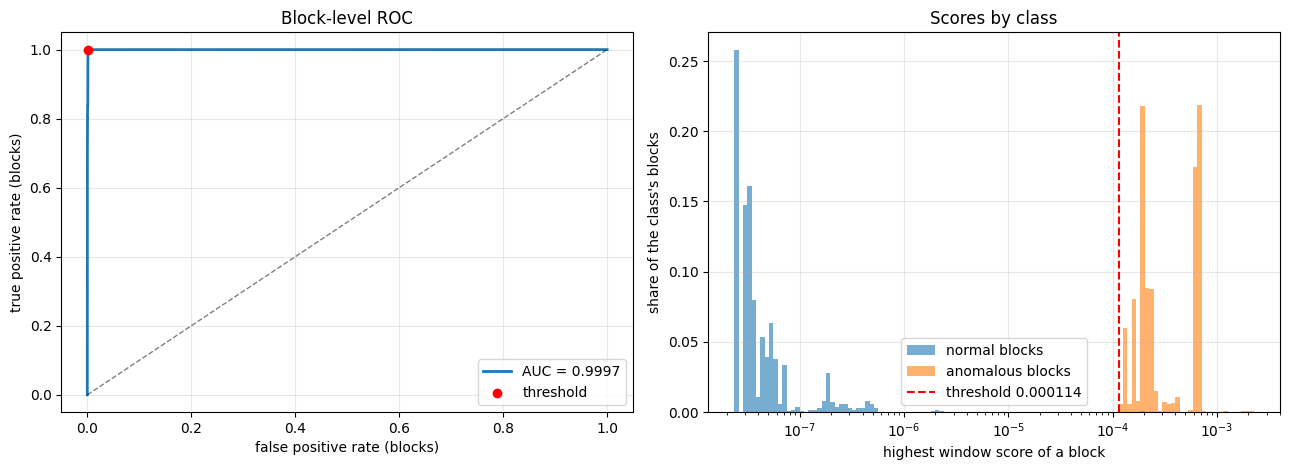

In [23]:
import matplotlib.pyplot as plt

y_true = np.r_[np.zeros(norm_max.size), np.ones(anom_max.size)]
order = np.argsort(-np.r_[norm_max, anom_max])
tpr = np.cumsum(y_true[order]) / anom_max.size
fpr = np.cumsum(1 - y_true[order]) / norm_max.size
auc = float(np.trapz(tpr, fpr))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].scatter([m["FP"] / norm_max.size], [m["recall"]], color="red", zorder=5, label="threshold")
axes[0].set(xlabel="false positive rate (blocks)", ylabel="true positive rate (blocks)", title="Block-level ROC")
axes[0].legend()
axes[0].grid(alpha=0.3)

bins = np.logspace(np.log10(max(min(norm_max.min(), anom_max.min()), 1e-12)),
                   np.log10(max(norm_max.max(), anom_max.max())), 120)
for scores, name in ((norm_max, "normal blocks"), (anom_max, "anomalous blocks")):
    axes[1].hist(scores, bins=bins, alpha=0.6, weights=np.full(scores.size, 1 / scores.size), label=name)
axes[1].axvline(THRESHOLD, color="red", ls="--", label=f"threshold {THRESHOLD:.3g}")
axes[1].set(xscale="log", xlabel="highest window score of a block", ylabel="share of the class's blocks",
            title="Scores by class")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()